In [46]:
from google.colab import drive

In [47]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
import os

In [49]:
os.chdir('/content/drive/MyDrive/ANN')

In [50]:
import pandas as pd
import numpy as np

In [51]:
df = pd.read_csv('imbalanced_data.csv')

In [52]:
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [53]:
df['tweet']

,tweet
0,@user when a father is dysfunctional and is s...
1,@user @user thanks for #lyft credit i can't us...
2,bihday your majesty
3,#model i love u take with u all the time in ...
4,factsguide: society now #motivation
...,...
31957,ate @user isz that youuu?ðððððð...
31958,to see nina turner on the airwaves trying to...
31959,listening to sad songs on a monday morning otw...
31960,"@user #sikh #temple vandalised in in #calgary,..."


In [54]:
import seaborn as sns

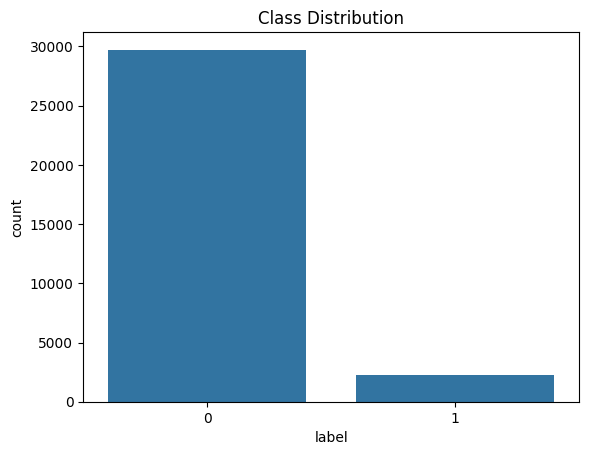

label
0    0.929854
1    0.070146
Name: proportion, dtype: float64


In [55]:
import matplotlib.pyplot as plt
sns.countplot(x=df['label'])
plt.title("Class Distribution")
plt.show()

print(df['label'].value_counts(normalize=True))

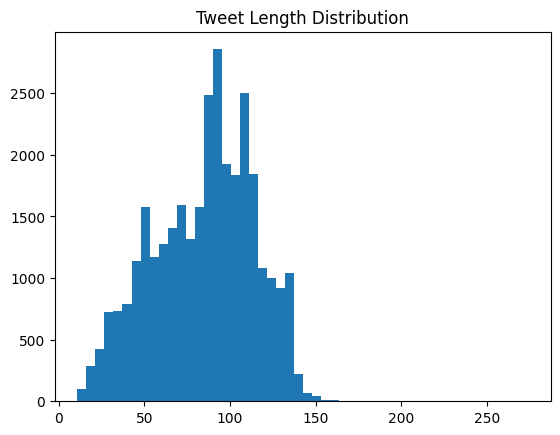

In [56]:
#Tweet Length Analysis
df['length'] = df['tweet'].apply(len)

plt.hist(df['length'], bins=50)
plt.title("Tweet Length Distribution")
plt.show()

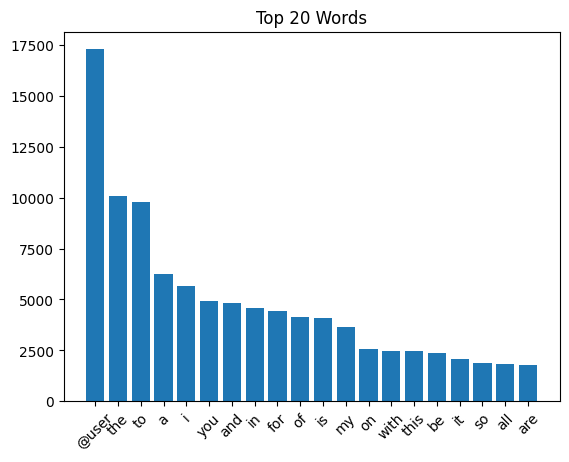

In [57]:
#Most Common Words
from collections import Counter

all_words = " ".join(df['tweet']).split()
common_words = Counter(all_words).most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Words")
plt.show()

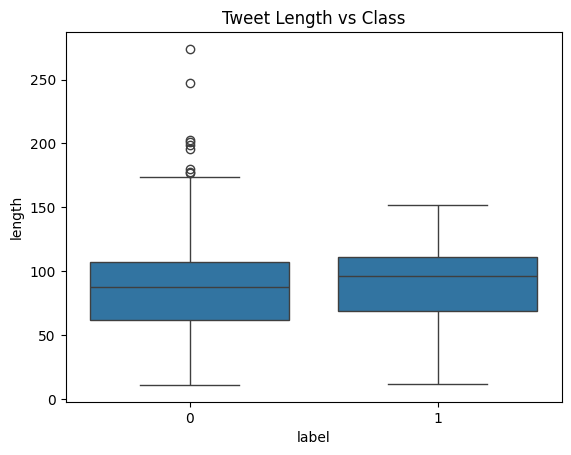

In [58]:
sns.boxplot(x='label', y='length', data=df)
plt.title("Tweet Length vs Class")
plt.show()

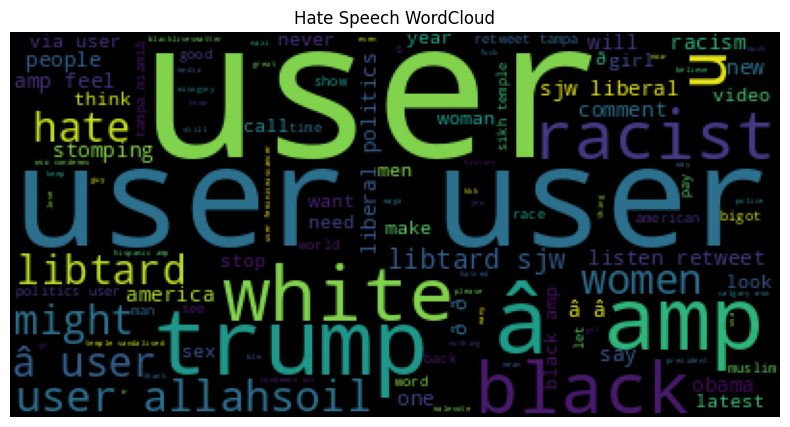

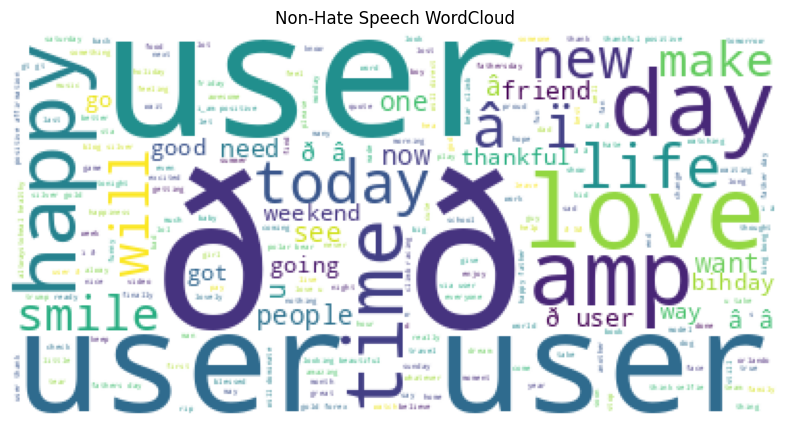

In [59]:
#WORD CLOUD (HATE vs NON-HATE)
from wordcloud import WordCloud

hate_words = " ".join(df[df['label'] == 1]['tweet'])
non_hate_words = " ".join(df[df['label'] == 0]['tweet'])

# Hate Speech
plt.figure(figsize=(10,5))
wc = WordCloud(background_color='black').generate(hate_words)
plt.imshow(wc)
plt.axis('off')
plt.title("Hate Speech WordCloud")
plt.show()

# Non-Hate Speech
plt.figure(figsize=(10,5))
wc = WordCloud(background_color='white').generate(non_hate_words)
plt.imshow(wc)
plt.axis('off')
plt.title("Non-Hate Speech WordCloud")
plt.show()

In [60]:
from nltk.corpus import stopwords
import re
import string
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [61]:
stemmer = nltk.SnowballStemmer("english")
stopword = set(stopwords.words('english'))

In [86]:
def data_cleaning(words):
    words = words.lower()
    words = re.sub(r'@\w+', '', words)  # remove mentions
    words = re.sub(r'http\S+', '', words)  # remove URLs
    words = re.sub(r'[^a-z\s]', '', words)  # remove special chars & numbers
    words = re.sub(r'\s+', ' ', words).strip()

    words = [word for word in words.split() if word not in stopword]
    words=" ".join(words)
    words = [stemmer.stem(word) for word in words.split()]
    words=" ".join(words)

    return words

In [63]:
df.head()

,id,label,tweet,length
0,1,0,@user when a father is dysfunctional and is s...,102
1,2,0,@user @user thanks for #lyft credit i can't us...,122
2,3,0,bihday your majesty,21
3,4,0,#model i love u take with u all the time in ...,86
4,5,0,factsguide: society now #motivation,39


In [87]:
df['tweet']=df['tweet'].apply(data_cleaning)

In [88]:
df.head()

,id,label,tweet,length
0,1,0,father dysfunct selfish drag kid dysfunct run ...,102
1,2,0,thank lyft credit cant use caus dont offer whe...,122
2,3,0,bihday majesti bihday majesti bihday majesti,21
3,4,0,model love u take u time ur model love u take ...,86
4,5,0,factsguid societi motiv factsguid societi moti...,39


In [66]:
df.iloc[0]['tweet']

'when a father is dysfunctional and is so selfish he drags his kids into his dysfunction run when a father is dysfunctional and is so selfish he drags his kids into his dysfunction run when a father is dysfunctional and is so selfish he drags his kids into his dysfunction run when a father is dysfunctional and is so selfish he drags his kids into his dysfunction run when a father is dysfunctional and is so selfish he drags his kids into his dysfunction run when a father is dysfunctional and is so selfish he drags his kids into his dysfunction run when a father is dysfunctional and is so selfish he drags his kids into his dysfunction run when a father is dysfunctional and is so selfish he drags his kids into his dysfunction run when a father is dysfunctional and is so selfish he drags his kids into his dysfunction run when a father is dysfunctional and is so selfish he drags his kids into his dysfunction run when a father is dysfunctional and is so selfish he drags his kids into his dys

In [67]:
X = df['tweet']
y = df['label']

In [89]:
from sklearn.model_selection import train_test_split

In [90]:
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

print(len(X_train),len(X_test))
print(len(y_train),len(y_test))

25569 6393
25569 6393


In [91]:
from keras import Sequential
from keras.layers import Dense,SimpleRNN, Embedding, Flatten

In [92]:
all_words = [word for sentence in df['tweet'] for word in sentence.split()]

unique_words = set(all_words)
vocab_size = len(unique_words)

print('vocabulary size',vocab_size)

vocabulary size 33736


In [98]:
from tensorflow.keras.preprocessing.text import Tokenizer
max_words = 50000
max_len = 300

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [104]:
from tensorflow.keras import Input

model = Sequential()

model.add(Input(shape=(max_len,)))  # 🔥 important

model.add(Embedding(max_words, 100))

model.add(SimpleRNN(100, dropout = 0.2,recurrent_dropout=0.2))

model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 300, 100)       │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_12 (SimpleRNN)       │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,020,201 (19.15 MB)

 Trainable params: 5,020,201 (19.15 MB)

 Non-trainable params: 0 (0.00 B)

In [106]:
from keras.optimizers import RMSprop

In [107]:
model.compile(loss='binary_crossentropy',optimizer=RMSprop(),metrics=['accuracy'])

In [109]:
history = model.fit(
    X_train_pad, y_train,
    batch_size=128,
    epochs=10,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 64s 305ms/step - accuracy: 0.8914 - loss: 0.3108 - val_accuracy: 0.9287 - val_loss: 0.2506
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 60s 299ms/step - accuracy: 0.9297 - loss: 0.2364 - val_accuracy: 0.9345 - val_loss: 0.2203
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 60s 300ms/step - accuracy: 0.9381 - loss: 0.1946 - val_accuracy: 0.9399 - val_loss: 0.1762
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 300ms/step - accuracy: 0.9455 - loss: 0.1666 - val_accuracy: 0.9407 - val_loss: 0.1730
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 84s 312ms/step - accuracy: 0.9544 - loss: 0.1374 - val_accuracy: 0.9490 - val_loss: 0.1555
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 311ms/step - accuracy: 0.9615 - loss: 0.1178 - val_accuracy: 0.9514 - val_loss: 0.1609
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 79s 294ms/step - accuracy: 0.9690 - loss: 0.0976 - val_accuracy: 0.9523 - val_loss: 0.1791
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 83s 300ms/step - accuracy: 0.9727 - loss: 0

In [110]:
loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)

200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.9531 - loss: 0.1817
Test Accuracy: 0.9530736804008484


In [111]:
rnn_prediction = model.predict(X_test_pad)

200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step


In [112]:
rnn_prediction

array([[9.2841098e-03],
       [4.2167059e-04],
       [4.0682728e-04],
       ...,
       [8.5461987e-03],
       [1.0847444e-05],
       [9.9612427e-01]], dtype=float32)

In [113]:
res = []
for prediction in rnn_prediction:
    if prediction[0] < 0.5:
        res.append(0)
    else:
        res.append(1)

In [114]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,res))

[[5846   91]
 [ 209  247]]


In [115]:
import pickle
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [117]:
import keras

In [121]:
model.save("model.h5")


In [122]:
load_model=keras.models.load_model("model.h5")

In [123]:
with open('tokenizer.pickle', 'rb') as handle:
    load_tokenizer = pickle.load(handle)